# AI-Powered Retail Demand Forecasting and Inventory Optimization

## Notebook 01 — Data Understanding

### Objective

The objective of this notebook is to understand the retail sales and inventory dataset before performing data cleaning, feature engineering, and machine learning.

The analysis will cover:

- Dataset structure and dimensions
- Data types
- Missing values
- Duplicate records
- Date range
- Store and product information
- Categorical variables
- Numerical variables
- Demand distribution
- Inventory and sales behaviour
- Correlations between variables
- Initial time-series patterns
- Potential data leakage

The findings from this notebook will be used to design the data preprocessing and machine learning pipeline in subsequent notebooks.

## 1. Import Required Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
%pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries imported successfully.


## 2. Load Dataset

The dataset is stored in the `data/raw/` directory.

We will load the original dataset without modifying it. Any cleaning or
transformation will be performed in a later notebook.

In [3]:
# Path to the raw dataset
DATA_PATH = "../data/raw/sales_data.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
# Display first 5 records
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [5]:
# Display last 5 records
df.tail()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84
75999,2024-01-30,S005,P0020,Toys,North,126,63,59,25.78,10,Snowy,0,29.32,Winter,0,73


## 3. Dataset Dimensions

We first determine the number of observations and variables in the dataset.

In [6]:
rows, columns = df.shape

print(f"Number of rows    : {rows:,}")
print(f"Number of columns : {columns}")

Number of rows    : 76,000
Number of columns : 16


In [7]:
print("Column names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Column names:
01. Date
02. Store ID
03. Product ID
04. Category
05. Region
06. Inventory Level
07. Units Sold
08. Units Ordered
09. Price
10. Discount
11. Weather Condition
12. Promotion
13. Competitor Pricing
14. Seasonality
15. Epidemic
16. Demand


## 4. Data Types and Structure

Understanding the data types is important before preprocessing.

For example:

- `Date` should be treated as a datetime variable.
- IDs are categorical identifiers.
- Numerical variables should be stored using appropriate numerical types.
- Categorical variables should be identified separately.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [9]:
# Create a compact column information table

column_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notna().sum().values,
    "Missing Count": df.isna().sum().values,
    "Unique Values": df.nunique().values
})

column_info

,Column,Data Type,Non-Null Count,Missing Count,Unique Values
Date,Date,object,76000,0,760
Store ID,Store ID,object,76000,0,5
Product ID,Product ID,object,76000,0,20
Category,Category,object,76000,0,5
Region,Region,object,76000,0,4
Inventory Level,Inventory Level,int64,76000,0,1426
Units Sold,Units Sold,int64,76000,0,330
Units Ordered,Units Ordered,int64,76000,0,996
Price,Price,float64,76000,0,15396
Discount,Discount,int64,76000,0,6


## 5. Missing Value Analysis

Missing values can affect both statistical analysis and machine learning.

At this stage, we are only identifying missing values. We will decide how to
handle them in the data-cleaning notebook.

In [10]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
Date,0,0.0
Store ID,0,0.0
Product ID,0,0.0
Category,0,0.0
Region,0,0.0
Inventory Level,0,0.0
Units Sold,0,0.0
Units Ordered,0,0.0
Price,0,0.0
Discount,0,0.0


In [11]:
total_missing = df.isnull().sum().sum()

print(f"Total missing values: {total_missing:,}")

if total_missing == 0:
    print("No missing values found.")
else:
    print("Missing values are present and require further investigation.")

Total missing values: 0
No missing values found.


## 6. Duplicate Record Analysis

Duplicate records can distort demand patterns and model training.

We will identify exact duplicate rows without removing them at this stage.

In [12]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")

Number of duplicate rows: 0


In [13]:
if duplicate_count == 0:
    print("No exact duplicate records found.")
else:
    print("Duplicate records exist and should be investigated.")

No exact duplicate records found.


## 7. Date Analysis

Demand forecasting is fundamentally a time-dependent problem.

Therefore, the `Date` column is especially important.

We will examine:

- Date data type
- Minimum date
- Maximum date
- Number of unique dates
- Records per date

In [14]:
print("Current Date data type:")
print(df["Date"].dtype)

Current Date data type:
object


In [15]:
# Convert Date to datetime for analysis
df["Date"] = pd.to_datetime(df["Date"])

print("Date conversion completed.")
print(f"Minimum date: {df['Date'].min()}")
print(f"Maximum date: {df['Date'].max()}")
print(f"Unique dates: {df['Date'].nunique():,}")

Date conversion completed.
Minimum date: 2022-01-01 00:00:00
Maximum date: 2024-01-30 00:00:00
Unique dates: 760


In [16]:
# Date range in days

date_range = df["Date"].max() - df["Date"].min()

print(f"Dataset covers approximately {date_range.days:,} days.")

Dataset covers approximately 759 days.


In [17]:
# Number of records per date

daily_records = df.groupby("Date").size()

daily_records.describe()

count    760.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64

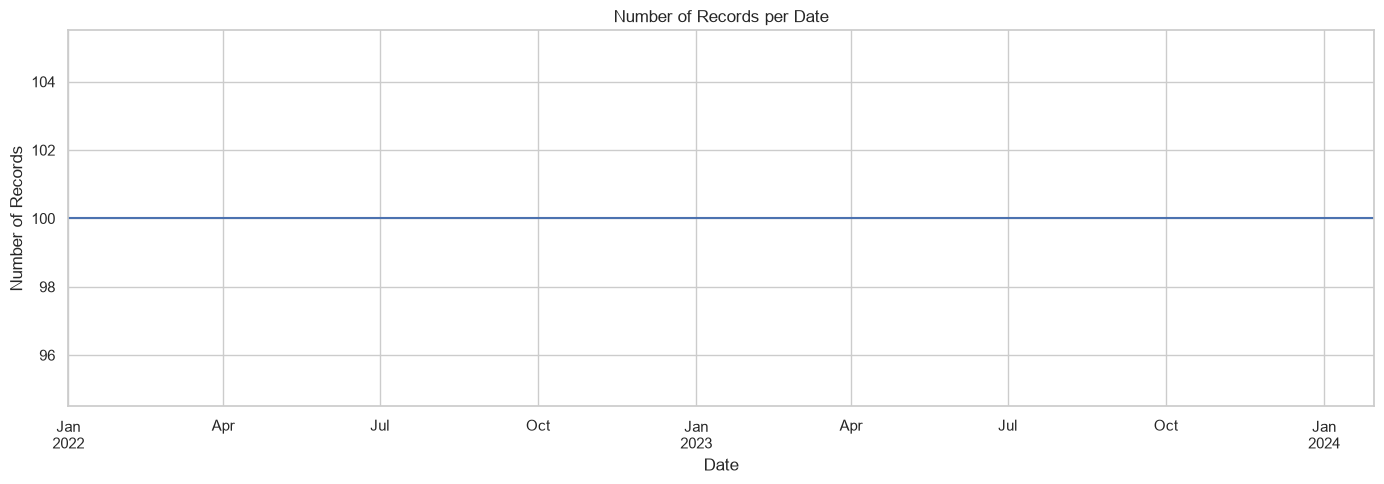

In [18]:
plt.figure(figsize=(14, 5))

daily_records.plot()

plt.title("Number of Records per Date")
plt.xlabel("Date")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## 8. Store Analysis

The platform is intended to support retail inventory and demand decisions
across multiple stores.

We therefore need to understand:

- Number of stores
- Records per store
- Demand by store
- Inventory by store

In [19]:
print(f"Number of unique stores: {df['Store ID'].nunique():,}")

Number of unique stores: 5


In [21]:
store_summary = df.groupby("Store ID").agg(
    Records=("Store ID", "size"),
    Total_Demand=("Demand", "sum"),
    Average_Demand=("Demand", "mean"),
    Average_Inventory=("Inventory Level", "mean"),
    Total_Units_Sold=("Units Sold", "sum")
).sort_values(
    "Total_Demand",
    ascending=False
)

store_summary.head(10)

,Records,Total_Demand,Average_Demand,Average_Inventory,Total_Units_Sold
Store ID,,,,,
S002,15200,1625471,106.938882,332.014737,1386126
S003,15200,1618324,106.468684,321.993026,1375613
S005,15200,1607085,105.729276,280.404868,1362812
S001,15200,1547573,101.814013,277.657368,1318134
S004,15200,1529651,100.634934,293.244211,1308191


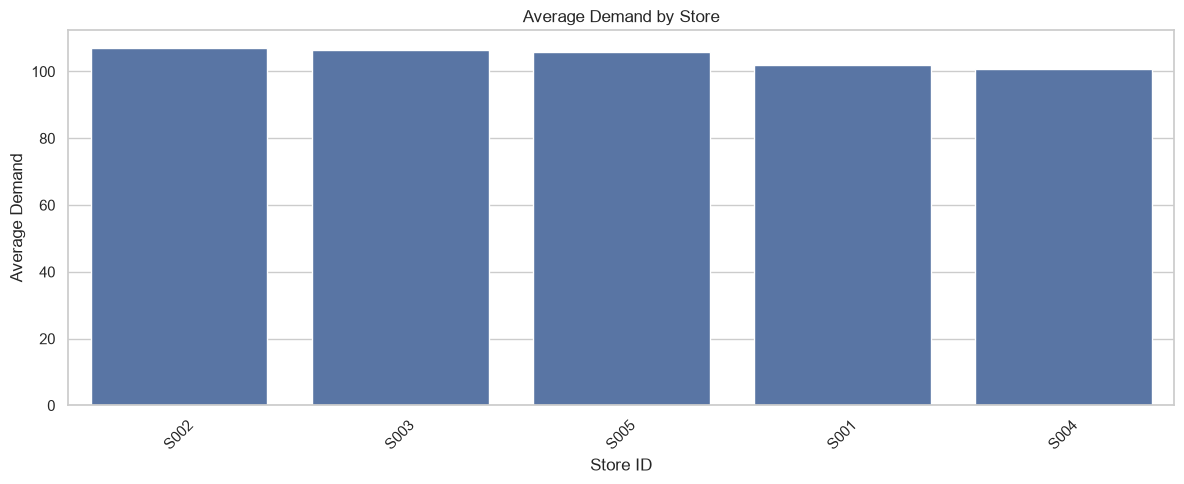

In [22]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=store_summary.index.astype(str),
    y=store_summary["Average_Demand"]
)

plt.title("Average Demand by Store")
plt.xlabel("Store ID")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 9. Product Analysis

Different products can have substantially different demand patterns.

We will examine the number of products and their demand distribution.

In [23]:
print(f"Number of unique products: {df['Product ID'].nunique():,}")

Number of unique products: 20


In [24]:
product_summary = df.groupby("Product ID").agg(
    Records=("Product ID", "size"),
    Total_Demand=("Demand", "sum"),
    Average_Demand=("Demand", "mean"),
    Average_Price=("Price", "mean"),
    Average_Inventory=("Inventory Level", "mean")
).sort_values(
    "Total_Demand",
    ascending=False
)

product_summary.head(10)

,Records,Total_Demand,Average_Demand,Average_Price,Average_Inventory
Product ID,,,,,
P0009,3800,450324,118.506316,83.047739,272.303684
P0013,3800,440895,116.025000,44.303395,382.652632
P0004,3800,438505,115.396053,45.307184,320.350000
P0007,3800,437089,115.023421,35.674368,466.860000
P0002,3800,425853,112.066579,42.719934,285.830789
P0010,3800,422064,111.069474,66.468400,310.549474
P0001,3800,416447,109.591316,37.220403,331.758684
P0006,3800,409345,107.722368,46.914603,283.058421
P0005,3800,408578,107.520526,50.747358,392.904211


## 10. Category Analysis

The dataset contains product categories.

Category-level analysis can help identify differences in demand behaviour
between product groups.

In [25]:
category_counts = df["Category"].value_counts()

category_counts

Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64

In [26]:
category_demand = df.groupby("Category")["Demand"].agg(
    ["count", "mean", "sum"]
).sort_values(
    "mean",
    ascending=False
)

category_demand

,count,mean,sum
Category,,,
Groceries,30400,120.976447,3677684
Clothing,12160,112.619737,1369456
Electronics,9120,97.482018,889036
Toys,10640,92.606955,985338
Furniture,13680,73.581140,1006590


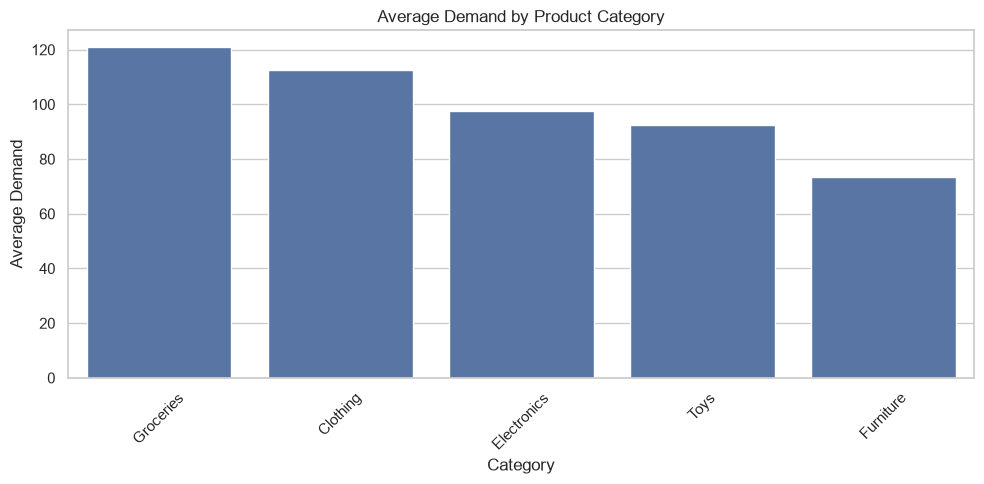

In [27]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_demand.reset_index(),
    x="Category",
    y="mean"
)

plt.title("Average Demand by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 11. Regional Analysis

Regional differences can influence demand due to differences in customer
behaviour, weather, seasonality, and other external factors.

In [29]:
region_summary = df.groupby("Region").agg(
    Records=("Region", "size"),
    Average_Demand=("Demand", "mean"),
    Total_Demand=("Demand", "sum"),
    Average_Inventory=("Inventory Level", "mean"),
    Average_Price=("Price", "mean")
).sort_values(
    "Average_Demand",
    ascending=False
)

region_summary

,Records,Average_Demand,Total_Demand,Average_Inventory,Average_Price
Region,,,,,
South,15200,106.938882,1625471,332.014737,64.401070
East,15200,106.468684,1618324,321.993026,70.092303
North,30400,103.771645,3154658,279.031118,63.362098
West,15200,100.634934,1529651,293.244211,77.412568


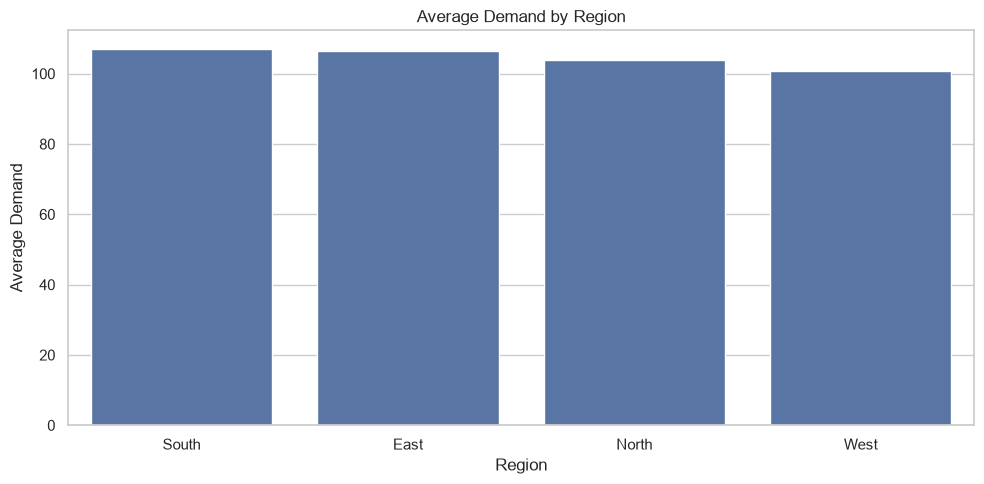

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=region_summary.reset_index(),
    x="Region",
    y="Average_Demand"
)

plt.title("Average Demand by Region")
plt.xlabel("Region")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 12. Numerical Variable Analysis

We now examine the statistical characteristics of the numerical variables.

This provides an initial understanding of:

- Central tendency
- Variability
- Minimum and maximum values
- Potential outliers

In [31]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic', 'Demand']


In [32]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Inventory Level,76000.0,301.062842,226.510161,0.00,136.0000,227.0,408.0000,2267.00
Units Sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00
Units Ordered,76000.0,89.090645,162.404627,0.00,0.0000,0.0,121.0000,1616.00
Price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03
Discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00
Promotion,76000.0,0.328947,0.469834,0.00,0.0000,0.0,1.0000,1.00
Competitor Pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22
Epidemic,76000.0,0.200000,0.400003,0.00,0.0000,0.0,0.0000,1.00
Demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00


## 13. Demand Analysis

`Demand` is the primary target variable for the forecasting problem.

Before selecting a machine learning model, we need to understand its
distribution and behaviour.

In [33]:
df["Demand"].describe()

count    76000.000000
mean       104.317158
std         46.964801
min          4.000000
25%         71.000000
50%        100.000000
75%        133.000000
max        430.000000
Name: Demand, dtype: float64

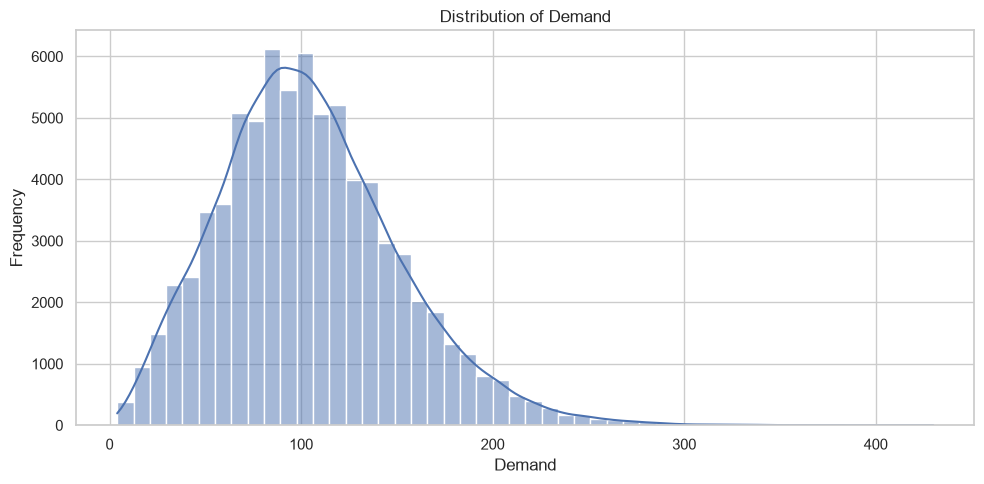

In [34]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Demand"],
    bins=50,
    kde=True
)

plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

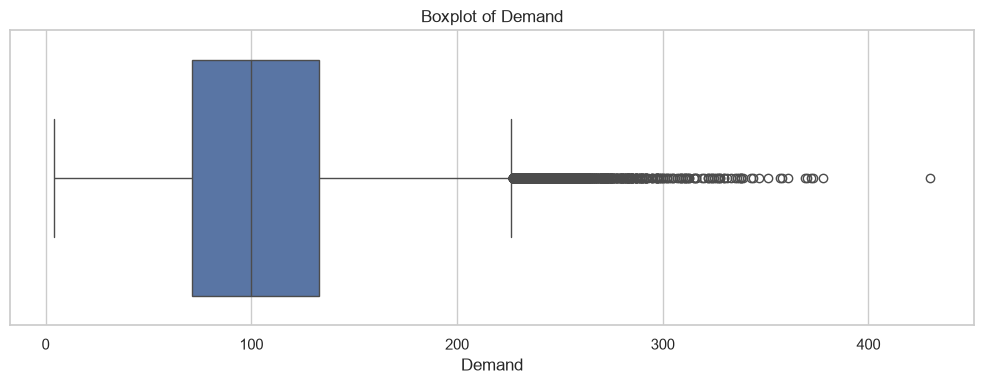

In [35]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["Demand"]
)

plt.title("Boxplot of Demand")
plt.xlabel("Demand")

plt.tight_layout()
plt.show()

## 14. Inventory and Demand Relationship

Inventory level is an important variable for the inventory optimization
component.

However, inventory-related variables must be carefully evaluated because
using information that would only be known after the forecasting period can
cause data leakage.

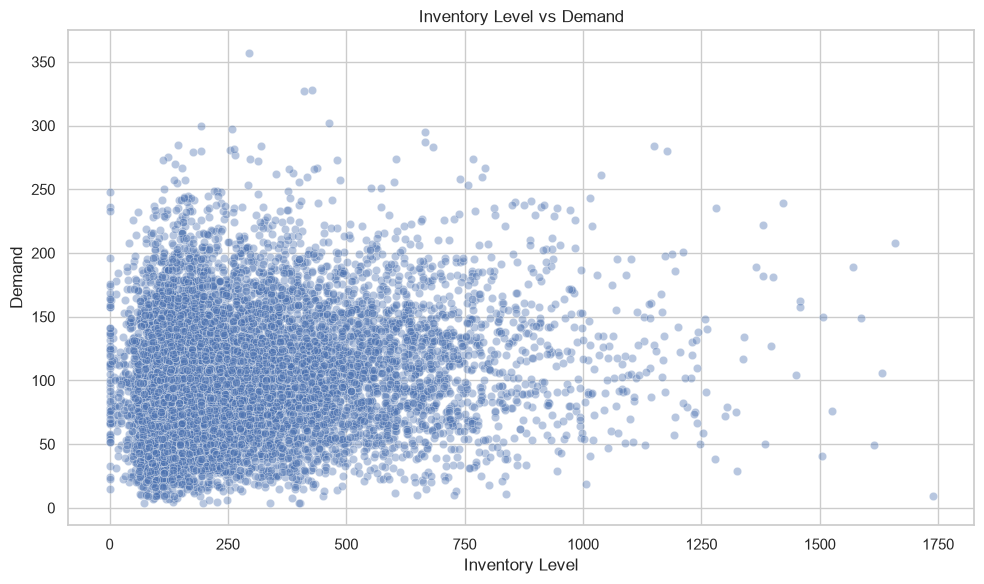

In [36]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x="Inventory Level",
    y="Demand",
    alpha=0.4
)

plt.title("Inventory Level vs Demand")
plt.xlabel("Inventory Level")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

## 15. Units Sold vs Demand

`Units Sold` appears closely related to demand and therefore requires
special attention.

If demand is calculated from or directly reflects units sold, using `Units Sold`
as a forecasting feature could introduce target leakage.

We will investigate this relationship rather than automatically using it.

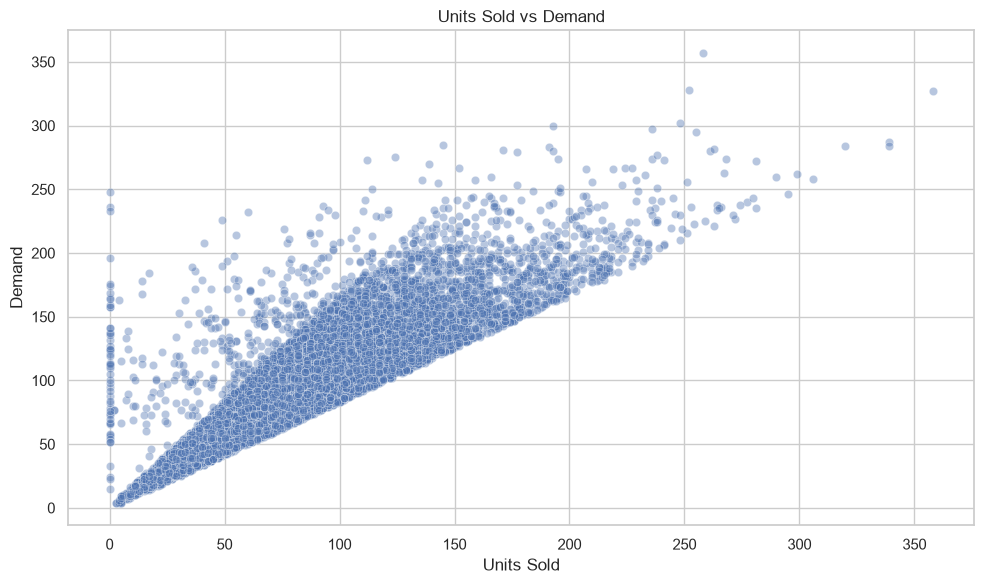

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x="Units Sold",
    y="Demand",
    alpha=0.4
)

plt.title("Units Sold vs Demand")
plt.xlabel("Units Sold")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

## 16. Price and Discount Analysis

Price and discount are potential demand-driving variables.

We will inspect their distributions and their relationship with demand.

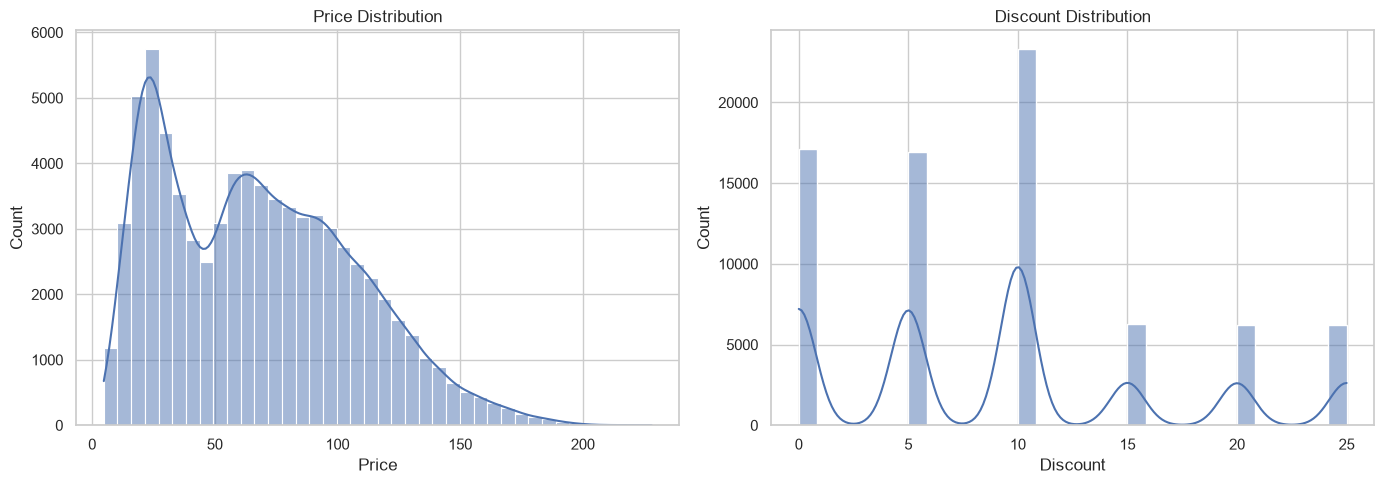

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["Price"],
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")

sns.histplot(
    df["Discount"],
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Discount Distribution")
axes[1].set_xlabel("Discount")

plt.tight_layout()
plt.show()

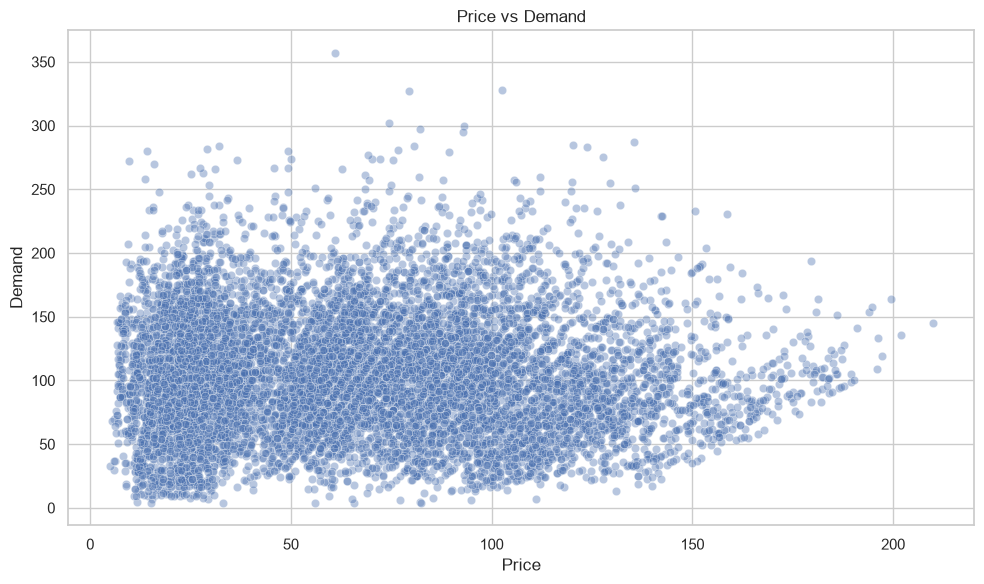

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x="Price",
    y="Demand",
    alpha=0.4
)

plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

## 17. Promotion and Demand

Promotional activity may influence customer demand.

We compare demand under promotional and non-promotional conditions.

In [40]:
promotion_summary = df.groupby("Promotion")["Demand"].agg(
    ["count", "mean", "sum"]
)

promotion_summary

,count,mean,sum
Promotion,,,
0,51000,95.026843,4846369
1,25000,123.269400,3081735


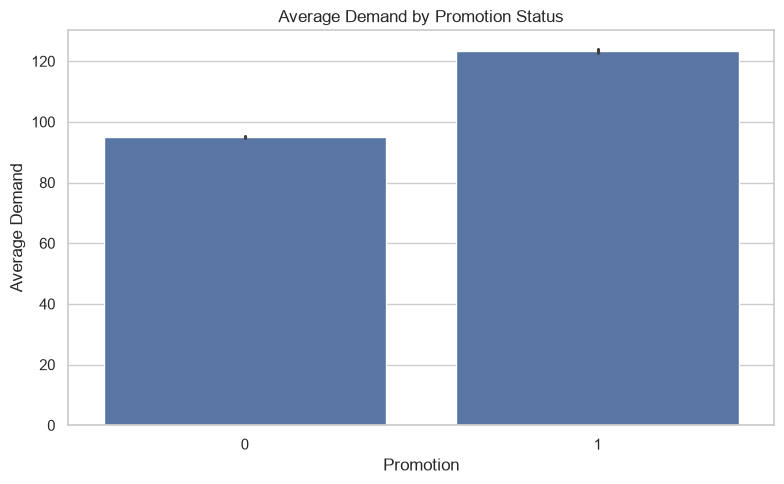

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Promotion",
    y="Demand",
    estimator="mean"
)

plt.title("Average Demand by Promotion Status")
plt.xlabel("Promotion")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 18. Weather Condition Analysis

Weather is included as an external factor in the dataset.

We investigate whether demand varies across weather conditions.

In [42]:
weather_summary = df.groupby("Weather Condition")["Demand"].agg(
    ["count", "mean", "sum"]
).sort_values(
    "mean",
    ascending=False
)

weather_summary

,count,mean,sum
Weather Condition,,,
Sunny,22980,115.167189,2646542
Cloudy,24360,105.404064,2567643
Rainy,17500,95.106743,1664368
Snowy,11160,94.045789,1049551


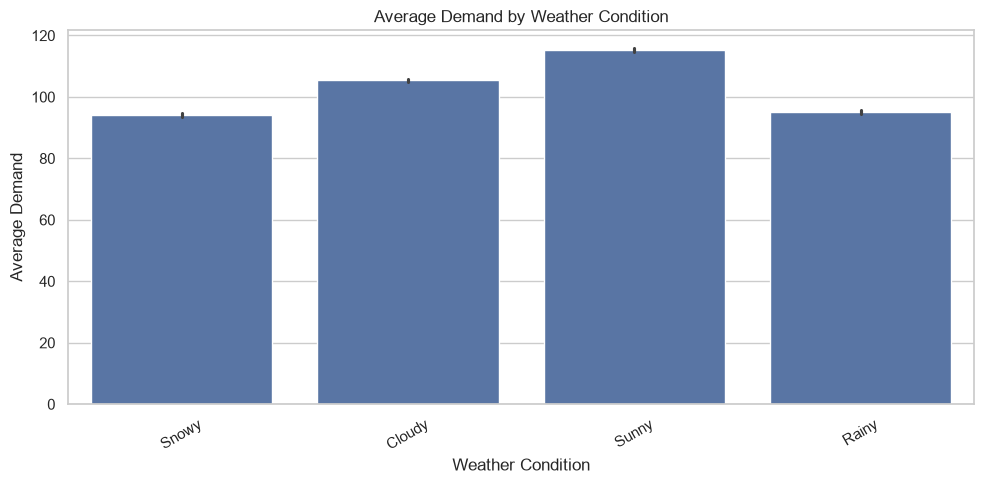

In [43]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Weather Condition",
    y="Demand",
    estimator="mean"
)

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Demand")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 19. Seasonality Analysis

The dataset contains a `Seasonality` variable.

We investigate how demand varies across the available seasonal categories.

In [44]:
seasonality_summary = df.groupby("Seasonality")["Demand"].agg(
    ["count", "mean", "sum"]
).sort_values(
    "mean",
    ascending=False
)

seasonality_summary

,count,mean,sum
Seasonality,,,
Summer,18400,112.855380,2076539
Autumn,18200,103.422967,1882298
Winter,21000,103.406190,2171530
Spring,18400,97.703098,1797737


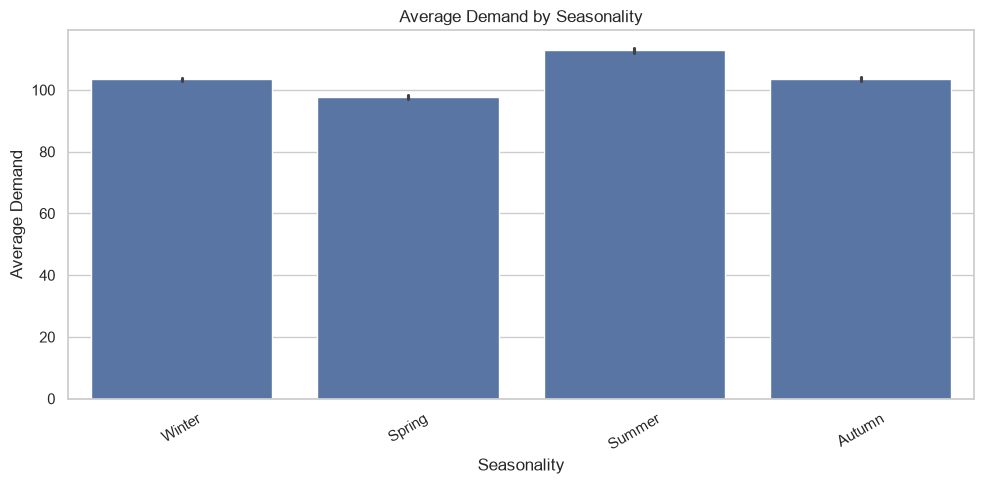

In [45]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Seasonality",
    y="Demand",
    estimator="mean"
)

plt.title("Average Demand by Seasonality")
plt.xlabel("Seasonality")
plt.ylabel("Average Demand")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 20. Epidemic Condition Analysis

The dataset contains an epidemic indicator that may represent an external
factor affecting retail demand.

In [46]:
epidemic_summary = df.groupby("Epidemic")["Demand"].agg(
    ["count", "mean", "sum"]
)

epidemic_summary

,count,mean,sum
Epidemic,,,
0,60800,112.856743,6861690
1,15200,70.158816,1066414


## 21. Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

Correlation does not imply causation, but it can help identify variables that
may be useful during feature engineering and model development.

In [47]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
Inventory Level,1.000000,0.234590,-0.034698,-0.036673,-0.000678,-0.006082,-0.034754,-0.097550,0.126618
Units Sold,0.234590,1.000000,0.433943,-0.014506,0.183523,0.227062,-0.013989,-0.317855,0.833421
Units Ordered,-0.034698,0.433943,1.000000,0.044980,0.172972,0.214743,0.045235,-0.100546,0.511963
Price,-0.036673,-0.014506,0.044980,1.000000,-0.094136,-0.043190,0.976648,-0.089658,-0.023461
Discount,-0.000678,0.183523,0.172972,-0.094136,1.000000,0.784039,-0.092066,-0.003885,0.224723
Promotion,-0.006082,0.227062,0.214743,-0.043190,0.784039,1.000000,-0.041385,0.000700,0.282537
Competitor Pricing,-0.034754,-0.013989,0.045235,0.976648,-0.092066,-0.041385,1.000000,-0.089466,-0.023036
Epidemic,-0.097550,-0.317855,-0.100546,-0.089658,-0.003885,0.000700,-0.089466,1.000000,-0.363661
Demand,0.126618,0.833421,0.511963,-0.023461,0.224723,0.282537,-0.023036,-0.363661,1.000000


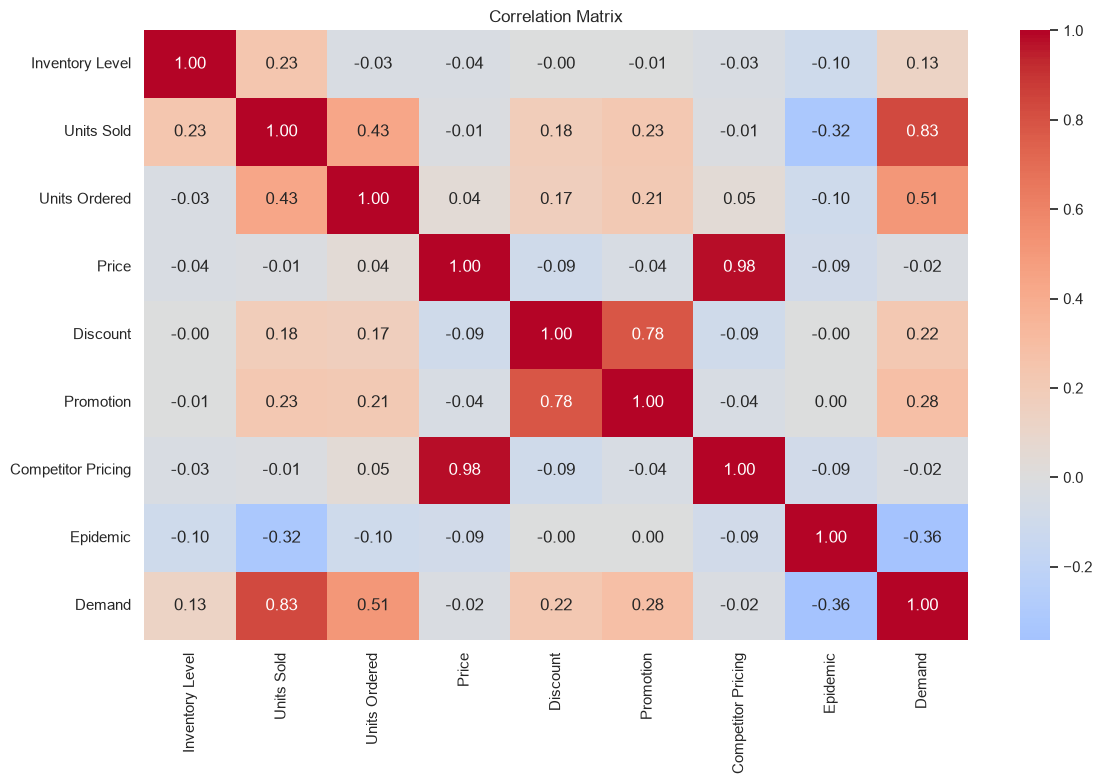

In [48]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [49]:
demand_correlation = (
    correlation_matrix["Demand"]
    .sort_values(ascending=False)
)

demand_correlation

Demand                1.000000
Units Sold            0.833421
Units Ordered         0.511963
Promotion             0.282537
Discount              0.224723
Inventory Level       0.126618
Competitor Pricing   -0.023036
Price                -0.023461
Epidemic             -0.363661
Name: Demand, dtype: float64

## 23. Overall Demand Over Time

Demand forecasting requires understanding how demand changes over time.

We aggregate demand by date and visualize the overall trend.

In [50]:
daily_demand = df.groupby("Date")["Demand"].sum()

daily_demand.head()

Date
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
Name: Demand, dtype: int64

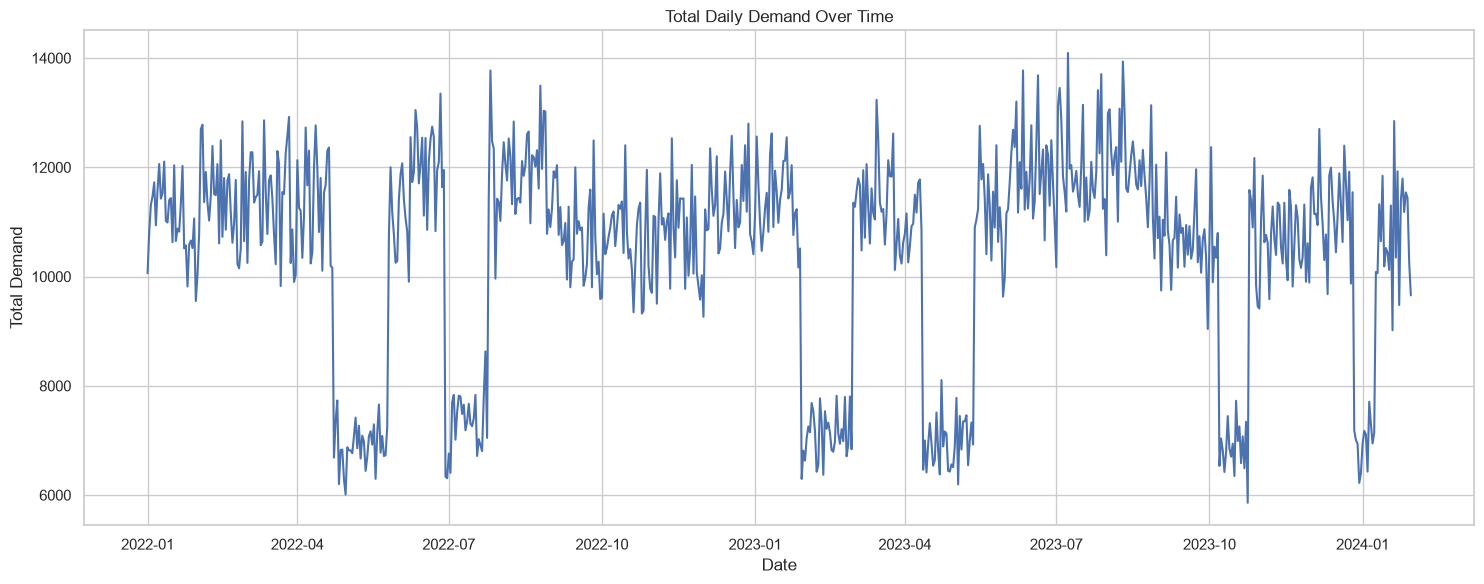

In [51]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_demand.index,
    daily_demand.values
)

plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

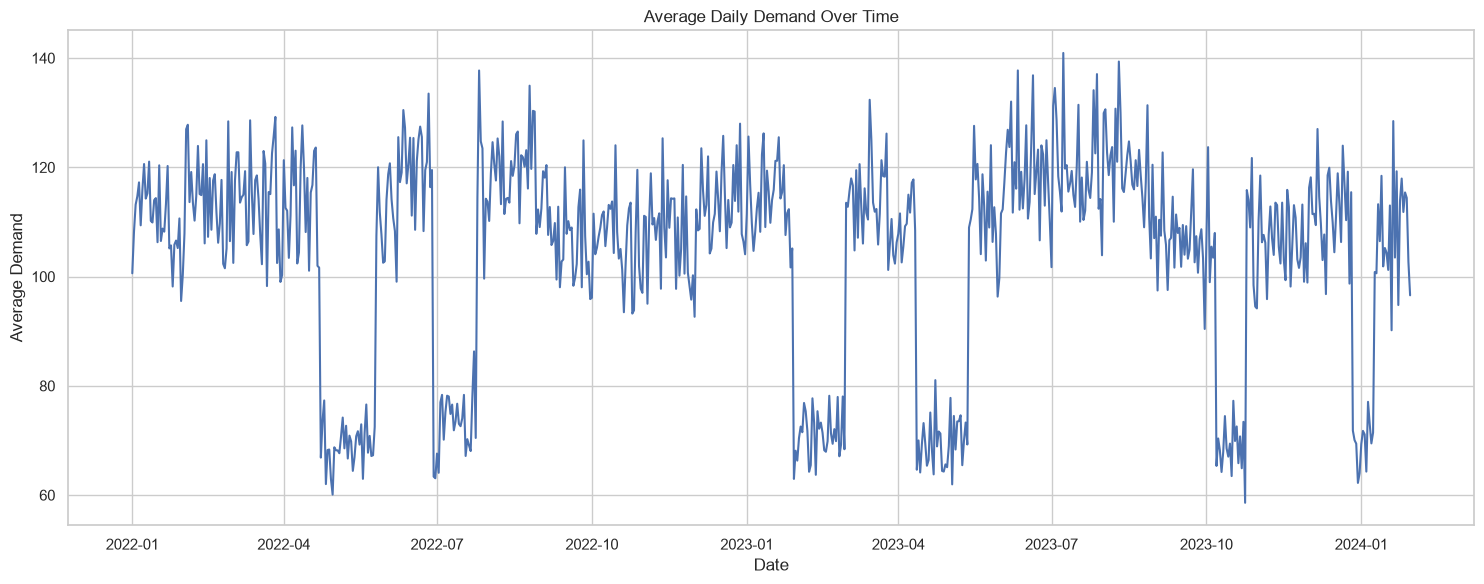

In [52]:
daily_average_demand = df.groupby("Date")["Demand"].mean()

plt.figure(figsize=(15, 6))

plt.plot(
    daily_average_demand.index,
    daily_average_demand.values
)

plt.title("Average Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

## 24. Weekly Demand Pattern

Daily demand can contain short-term fluctuations.

Weekly aggregation helps identify broader demand patterns.

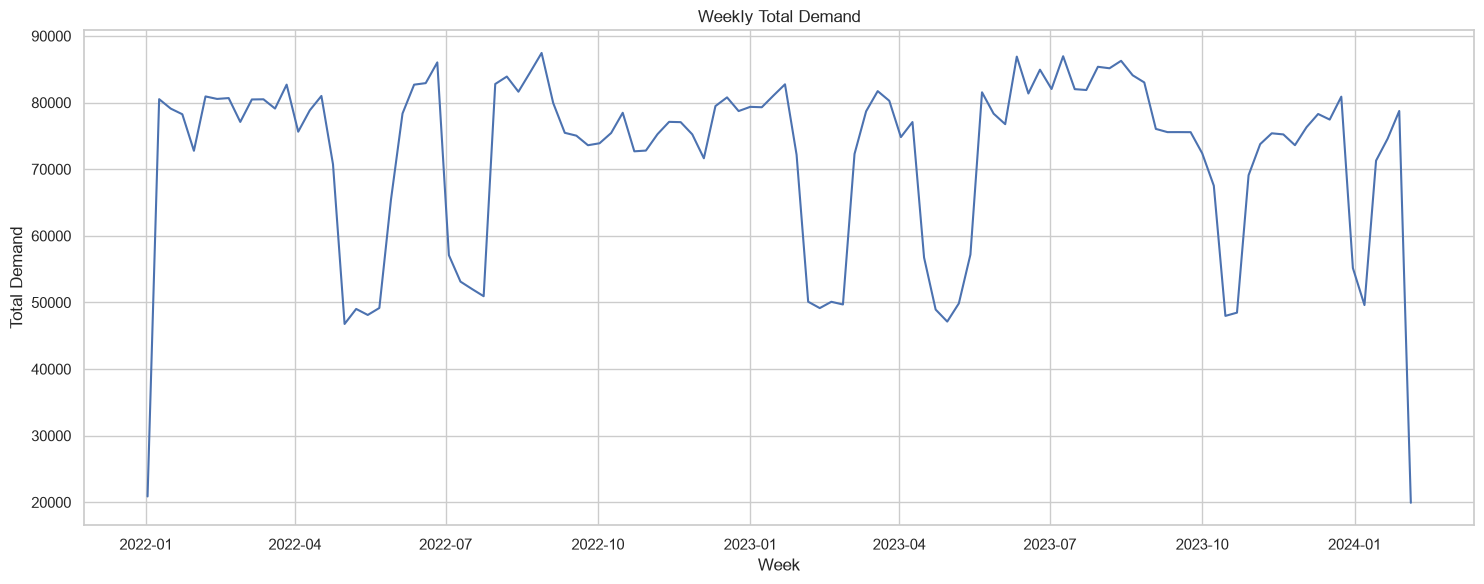

In [53]:
weekly_demand = (
    df.set_index("Date")["Demand"]
    .resample("W")
    .sum()
)

plt.figure(figsize=(15, 6))

plt.plot(
    weekly_demand.index,
    weekly_demand.values
)

plt.title("Weekly Total Demand")
plt.xlabel("Week")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

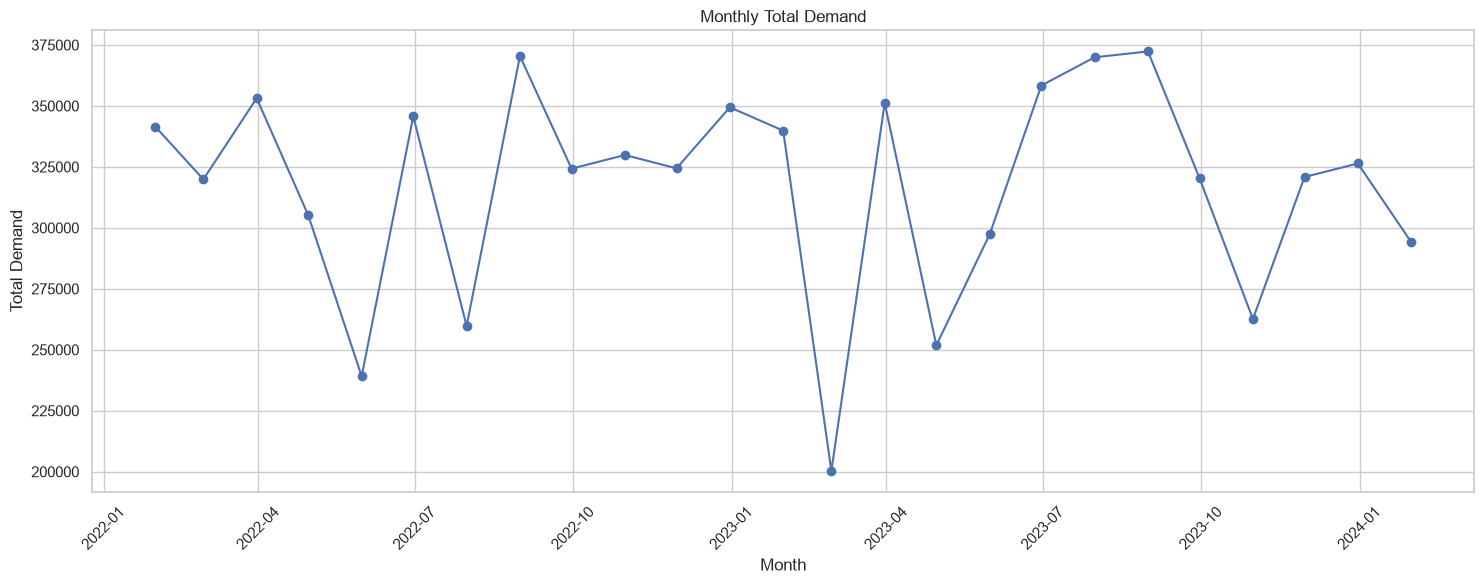

In [54]:
monthly_demand = (
    df.set_index("Date")["Demand"]
    .resample("ME")
    .sum()
)

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Monthly Total Demand")
plt.xlabel("Month")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 25. Day-of-Week Demand Pattern

Demand may vary depending on the day of the week.

We derive the day of week only for exploratory analysis. Feature engineering
will be performed in a later notebook.

In [55]:
df["DayOfWeek"] = df["Date"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_demand = (
    df.groupby("DayOfWeek")["Demand"]
    .mean()
    .reindex(day_order)
)

day_demand

DayOfWeek
Monday       103.423303
Tuesday      103.665229
Wednesday    105.192037
Thursday     104.408333
Friday       104.394444
Saturday     104.484037
Sunday       104.662294
Name: Demand, dtype: float64

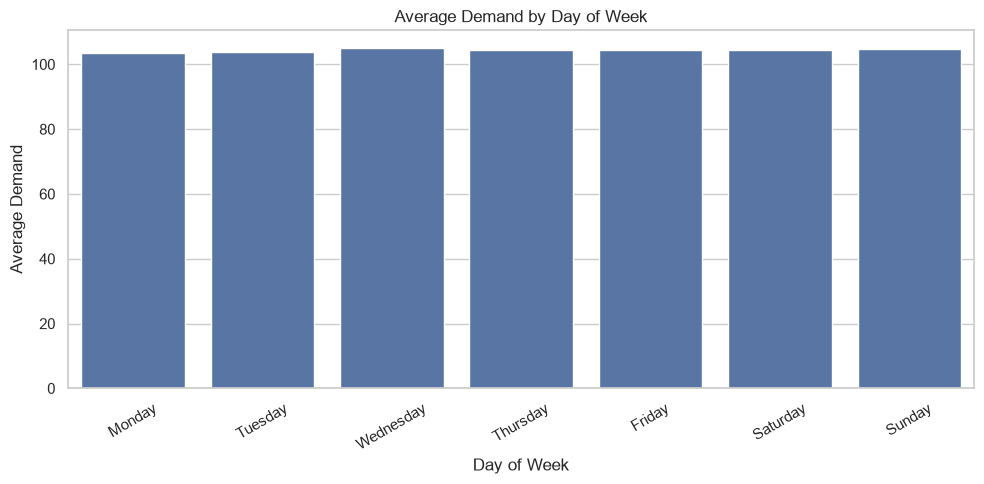

In [56]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_demand.index,
    y=day_demand.values
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# 26. Potential Data Leakage Analysis

Before developing a machine learning model, we must determine whether any
variables contain information that would not be available at the time a
forecast is generated.

Potentially problematic variables include:

- Units Sold
- Units Ordered
- Inventory Level

For example, if we want to predict future demand for tomorrow, we cannot use
tomorrow's actual units sold as an input.

Therefore, these variables must be interpreted according to the forecasting
scenario.

This notebook only identifies potentially problematic variables. The final
feature-selection strategy will be defined during feature engineering.

In [57]:
potential_leakage_features = [
    "Units Sold",
    "Units Ordered",
    "Inventory Level"
]

for column in potential_leakage_features:
    print(f"{column}:")
    print(f"  Correlation with Demand: {df[column].corr(df['Demand']):.4f}")
    print()

Units Sold:
  Correlation with Demand: 0.8334

Units Ordered:
  Correlation with Demand: 0.5120

Inventory Level:
  Correlation with Demand: 0.1266



## 27. Initial Feature Classification

We classify the variables into preliminary groups.

This classification is not final. Feature engineering and forecasting
requirements may change the final feature set.

In [58]:
target_variable = "Demand"

identifier_columns = [
    "Store ID",
    "Product ID"
]

categorical_columns = [
    "Category",
    "Region",
    "Weather Condition",
    "Promotion",
    "Seasonality",
    "Epidemic"
]

numerical_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing"
]

print("Target variable:")
print(target_variable)

print("\nIdentifier columns:")
print(identifier_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Target variable:
Demand

Identifier columns:
['Store ID', 'Product ID']

Categorical columns:
['Category', 'Region', 'Weather Condition', 'Promotion', 'Seasonality', 'Epidemic']

Numerical columns:
['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Competitor Pricing']


## 28. Dataset Summary

In [59]:
summary = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Unique Stores": df["Store ID"].nunique(),
    "Unique Products": df["Product ID"].nunique(),
    "Unique Categories": df["Category"].nunique(),
    "Unique Regions": df["Region"].nunique(),
    "Unique Dates": df["Date"].nunique(),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Rows,76000
1,Columns,17
2,Unique Stores,5
3,Unique Products,20
4,Unique Categories,5
5,Unique Regions,4
6,Unique Dates,760
7,Missing Values,0
8,Duplicate Rows,0


# 29. Initial Findings and Conclusions

### Dataset

The dataset contains retail-level observations involving stores, products,
inventory, sales, pricing, promotions, environmental conditions, and demand.

### Demand

`Demand` has been identified as the primary target variable for the demand
forecasting component.

### Time Dimension

The `Date` variable provides the temporal dimension required for forecasting.

### Potential Predictors

Potential explanatory variables include:

- Price
- Discount
- Promotion
- Weather Condition
- Seasonality
- Competitor Pricing
- Region
- Store
- Product
- Historical inventory-related information

### Important Consideration

`Units Sold`, `Units Ordered`, and `Inventory Level` require additional
investigation before they are used as forecasting features because their
availability relative to the forecast date determines whether they introduce
data leakage.

### Next Step

The next notebook will focus on data cleaning and validation.

Notebook 02 will cover:

1. Data type correction
2. Duplicate handling
3. Data consistency checks
4. Outlier investigation
5. Categorical value validation
6. Date validation
7. Preparation of the cleaned dataset

No machine learning model will be trained until the data preparation process
has been completed.